without prediction


Mounted at /content/drive
                        Order ID Order Date  Ship Date       Ship Mode  \
Row ID                                                                   
40098   CA-2014-AB10015140-41954 2014-11-11 2014-11-13     First Class   
26341     IN-2014-JR162107-41675 2014-02-05 2014-02-07    Second Class   
25330     IN-2014-CR127307-41929 2014-10-17 2014-10-18     First Class   
13524    ES-2014-KM1637548-41667 2014-01-28 2014-01-30     First Class   
47221    SG-2014-RH9495111-41948 2014-11-05 2014-11-06        Same Day   
...                          ...        ...        ...             ...   
29002    IN-2015-KE1642066-42174 2015-06-19 2015-06-19        Same Day   
34337   US-2014-ZD21925140-41765 2014-05-06 2014-05-10  Standard Class   
31315   CA-2012-ZD21925140-41147 2012-08-26 2012-08-31    Second Class   
9596     MX-2013-RB1979518-41322 2013-02-17 2013-02-21  Standard Class   
6147     MX-2013-MC1810093-41416 2013-05-22 2013-05-26    Second Class   

         Cu

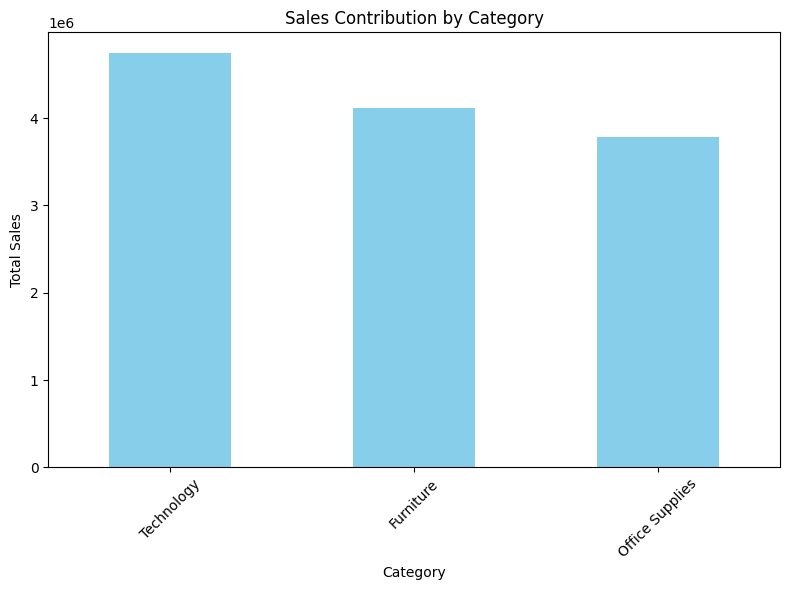

<ipython-input-4-d9827dec0506>:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Category', data=df, palette = "Set3")


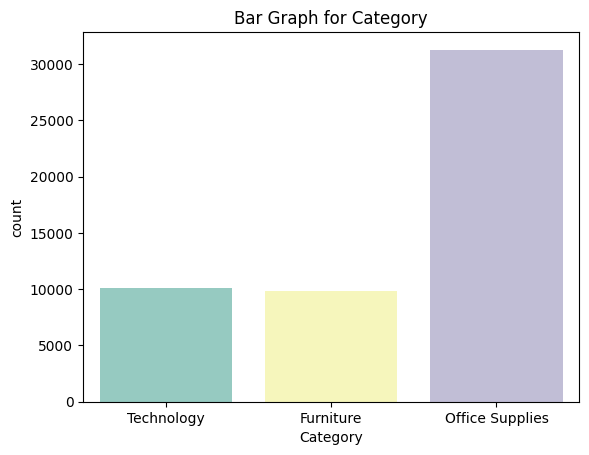

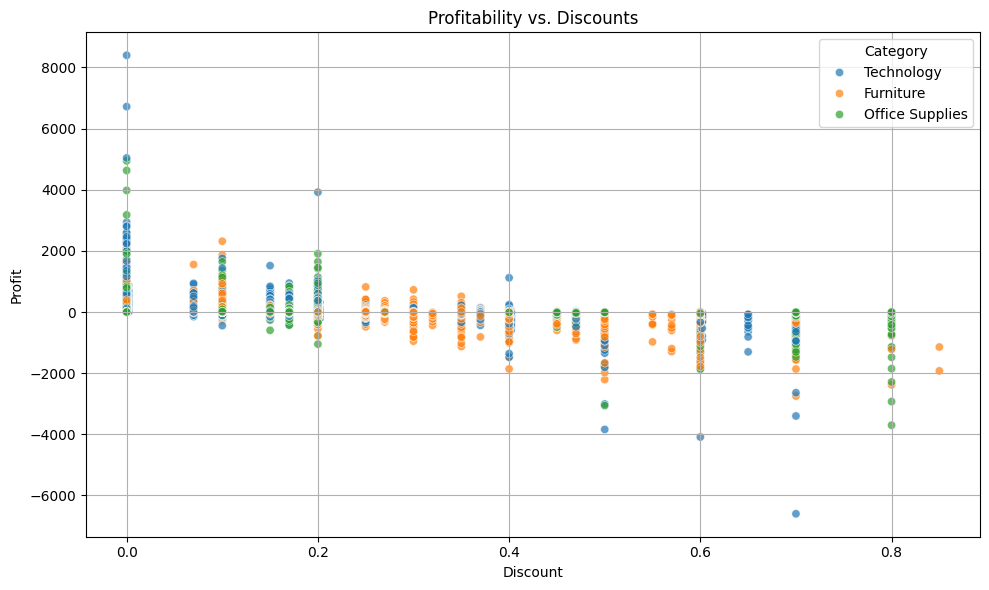

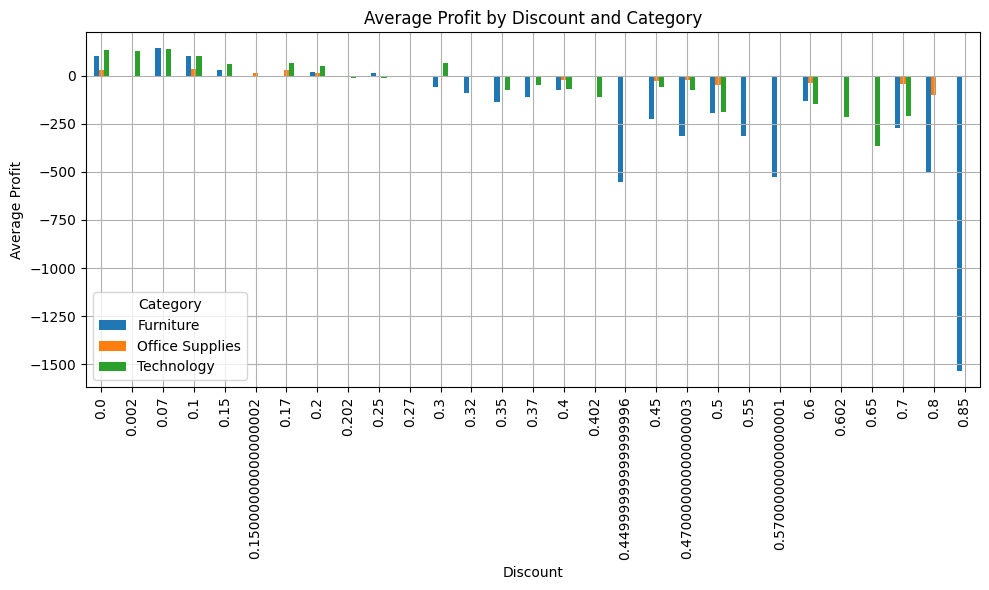

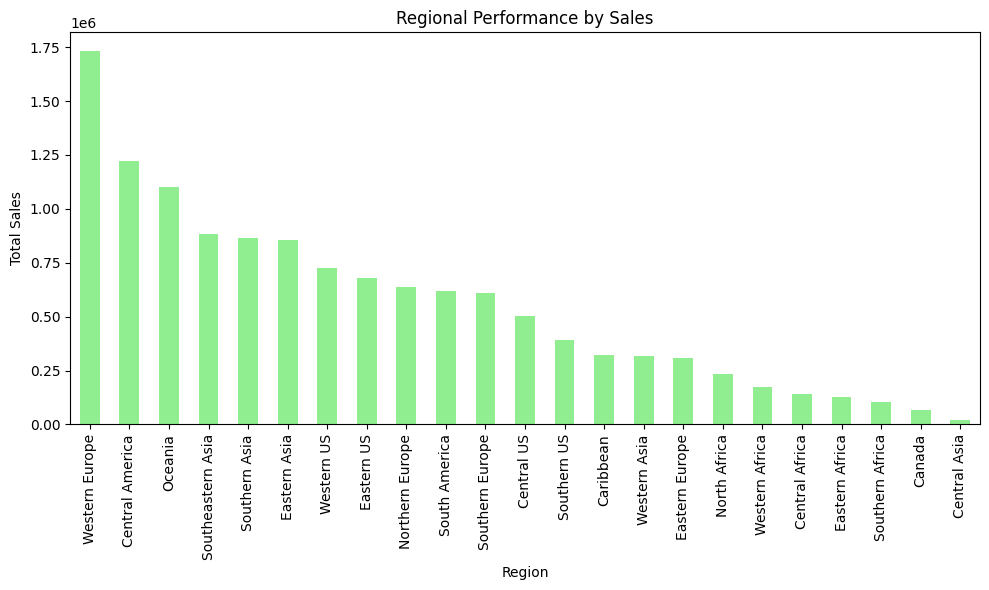

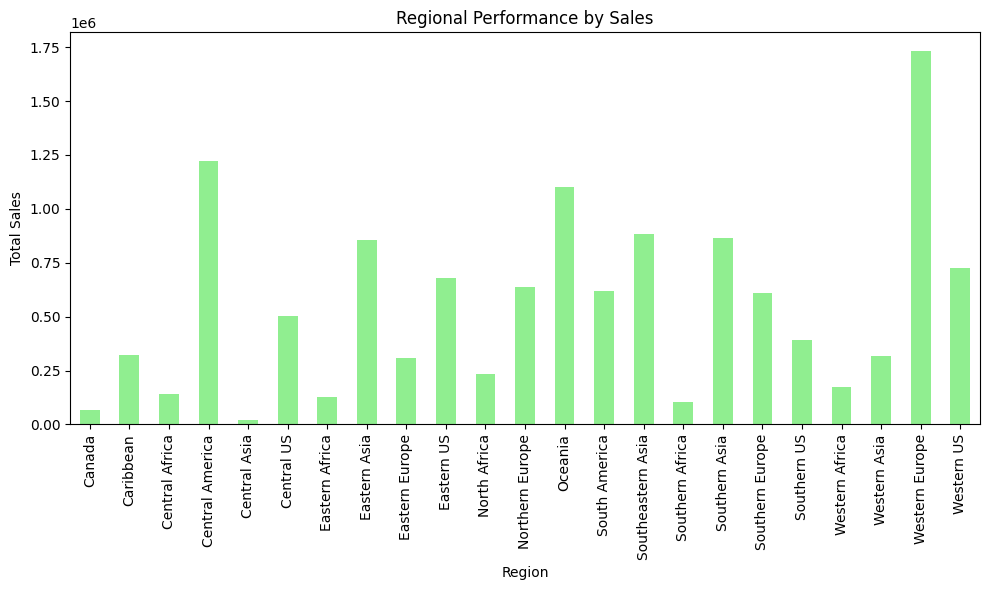

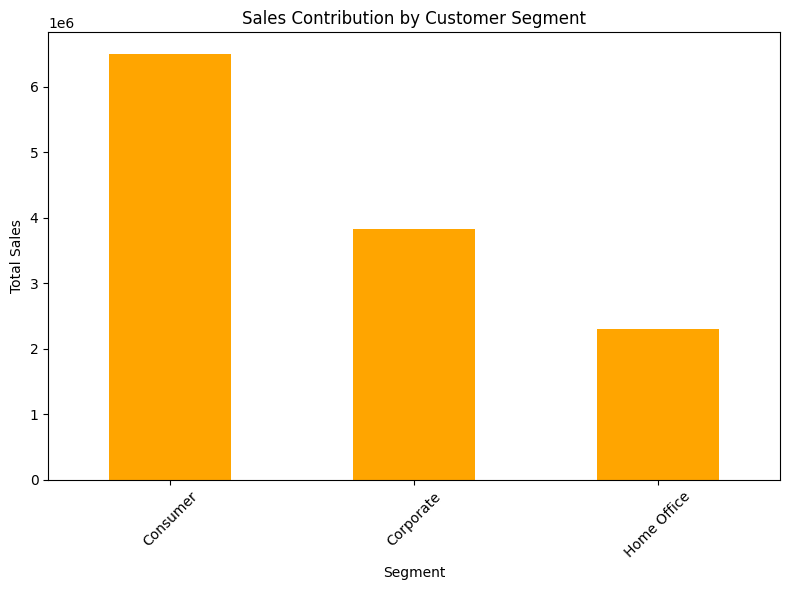

                        Order ID Order Date  Ship Date       Ship Mode  \
Row ID                                                                   
40098   CA-2014-AB10015140-41954 2014-11-11 2014-11-13     First Class   
26341     IN-2014-JR162107-41675 2014-02-05 2014-02-07    Second Class   
25330     IN-2014-CR127307-41929 2014-10-17 2014-10-18     First Class   
13524    ES-2014-KM1637548-41667 2014-01-28 2014-01-30     First Class   
47221    SG-2014-RH9495111-41948 2014-11-05 2014-11-06        Same Day   
...                          ...        ...        ...             ...   
29002    IN-2015-KE1642066-42174 2015-06-19 2015-06-19        Same Day   
34337   US-2014-ZD21925140-41765 2014-05-06 2014-05-10  Standard Class   
31315   CA-2012-ZD21925140-41147 2012-08-26 2012-08-31    Second Class   
9596     MX-2013-RB1979518-41322 2013-02-17 2013-02-21  Standard Class   
6147     MX-2013-MC1810093-41416 2013-05-22 2013-05-26    Second Class   

         Customer ID       Customer N

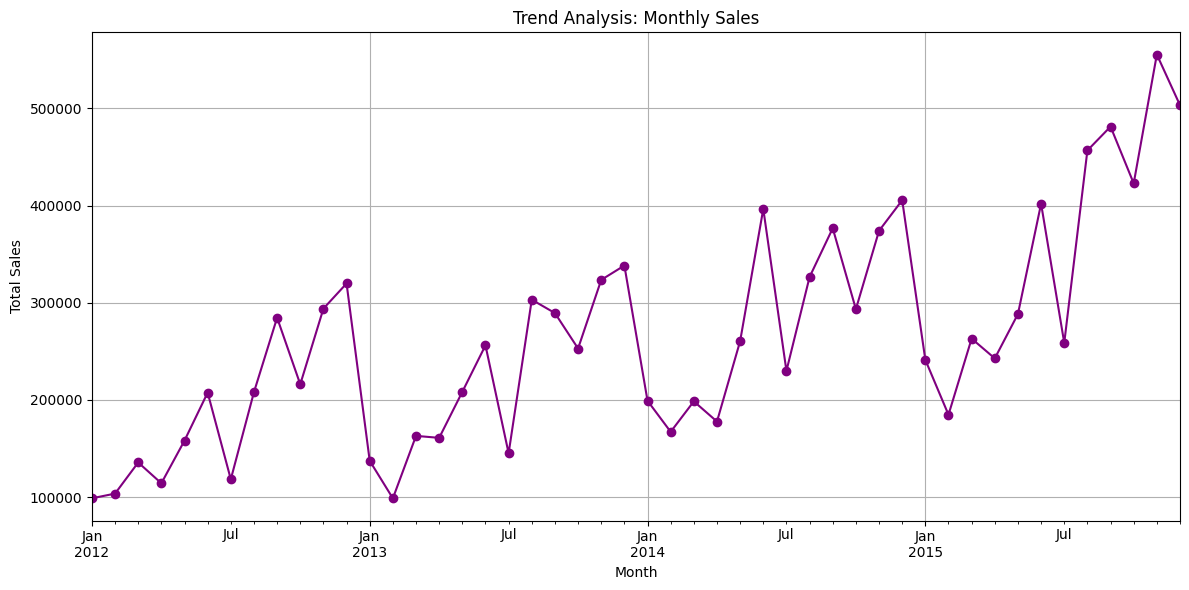

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Specify the path to the CSV file in your Drive
#path = '/content/drive/My Drive/Diwali_Sales_Data.csv'

# Load the Excel file
file_path = '/content/drive/My Drive/DA_Dataset/Walmart_global_Superstore.xlsx'

# Load the data (adjust the sheet name if needed)
df = pd.read_excel(file_path, index_col=0)
print(df)

# Inspect the data structure
print("Columns in the dataset:")
print(df.columns)

# Ensure relevant columns exist
required_columns = ['Category', 'Sales', 'Profit', 'Discount', 'Region', 'Segment', 'Order Date']
for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"Column '{col}' is missing from the dataset.")

# Sales Contribution by Category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 6))
category_sales.plot(kind='bar', color='skyblue')
plt.title('Sales Contribution by Category')
plt.ylabel('Total Sales')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

sns.countplot(x='Category', data=df, palette = "Set3")
plt.title('Bar Graph for Category')
plt.show()

# Profitability vs. Discounts
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.7)
plt.title('Profitability vs. Discounts')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.legend(title='Category')
plt.grid(True)
plt.tight_layout()
plt.show()

#Profitability vs. Discounts using BarPlot
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame
# Create a new DataFrame that aggregates the average profit by discount and category
average_profit_by_discount_category = df.groupby(['Discount', 'Category'])['Profit'].mean().reset_index()

# Pivot the DataFrame to get categories as columns
pivot_df = average_profit_by_discount_category.pivot(index='Discount', columns='Category', values='Profit')

# Create a bar chart
pivot_df.plot(kind='bar', figsize=(10, 6))

plt.title('Average Profit by Discount and Category')
plt.xlabel('Discount')
plt.ylabel('Average Profit')
plt.legend(title='Category')
plt.grid(True)
plt.tight_layout()
plt.show()

# Regional Performance
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
region_sales.plot(kind='bar', color='lightgreen')
plt.title('Regional Performance by Sales')
plt.ylabel('Total Sales')
plt.xlabel('Region')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#Regional performane without sort
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame
# Group by Region and sum Sales without sorting
region_sales = df.groupby('Region')['Sales'].sum()

# Create a bar chart
plt.figure(figsize=(10, 6))
region_sales.plot(kind='bar', color='lightgreen')
plt.title('Regional Performance by Sales')
plt.ylabel('Total Sales')
plt.xlabel('Region')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Customer Segment Behavior
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 6))
segment_sales.plot(kind='bar', color='orange')
plt.title('Sales Contribution by Customer Segment')
plt.ylabel('Total Sales')
plt.xlabel('Segment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Trend Analysis (Monthly Sales)
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.to_period('M')
print(df)
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(12, 6))
monthly_sales.plot(color='purple', marker='o')
plt.title('Trend Analysis: Monthly Sales')
plt.ylabel('Total Sales')
plt.xlabel('Month')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:

print(df.columns)
customer_product_region = df[['Customer Name', 'Product Name', 'Region']]
print(customer_product_region)


Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Customer Name', 'Segment', 'Postal Code', 'City', 'State', 'Country',
       'Region', 'Market', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Shipping Cost', 'Order Priority', 'Month'],
      dtype='object')
             Customer Name                                   Product Name  \
Row ID                                                                      
40098        Aaron Bergman                               Samsung Convoy 3   
26341        Justin Ritter      Novimex Executive Leather Armchair, Black   
25330         Craig Reiter              Nokia Smart Phone, with Caller ID   
13524     Katherine Murray                 Motorola Smart Phone, Cordless   
47221          Rick Hansen                 Sharp Wireless Fax, High-Speed   
...                    ...                                            ...   
29002      Katrina Edel

In [ ]:
# Format the date as 'YYYY-MM-DD'
df['Formatted Date'] = df['Order Date'].dt.strftime('%Y-%m-%d')

# Display the formatted dates
print(df[['Order Date', 'Formatted Date']].head())

       Order Date Formatted Date
Row ID                          
40098  2014-11-11     2014-11-11
26341  2014-02-05     2014-02-05
25330  2014-10-17     2014-10-17
13524  2014-01-28     2014-01-28
47221  2014-11-05     2014-11-05


       Order Date Quarter
Row ID                   
40098  2014-11-11  2014Q4
26341  2014-02-05  2014Q1
25330  2014-10-17  2014Q4
13524  2014-01-28  2014Q1
47221  2014-11-05  2014Q4


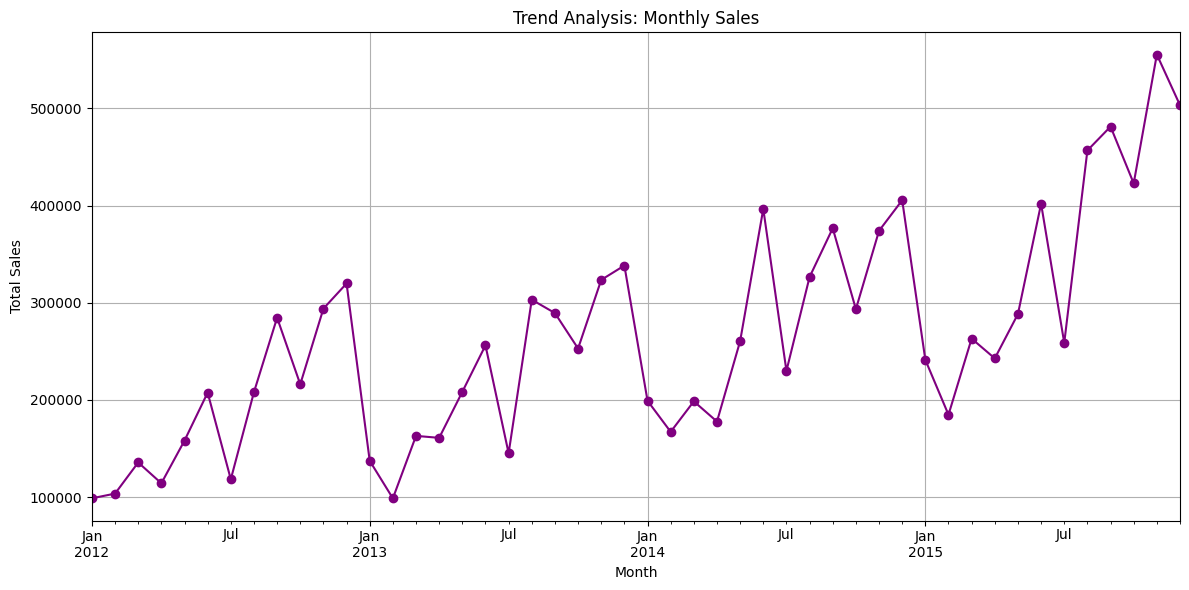

In [ ]:
# Trend Analysis (Monthly Sales)
df['Order Date'] = pd.to_datetime(df['Order Date'])  # This is where you're converting to datetime format.

# Add the new column for the quarter based on the "Order Date"
df['Quarter'] = df['Order Date'].dt.to_period('Q')  # This line adds the 'Quarter' column

# Inspect the dataframe (Optional)
print(df[['Order Date', 'Quarter']].head())  # This will show the 'Order Date' and the new 'Quarter' column

# Now continue with your existing code for monthly sales
df['Month'] = df['Order Date'].dt.to_period('M')  # This creates the Month column (which you already have)
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(12, 6))
monthly_sales.plot(color='purple', marker='o')
plt.title('Trend Analysis: Monthly Sales')
plt.ylabel('Total Sales')
plt.xlabel('Month')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')  # Mount drive for access

# Load the dataset, providing the full path from your Google Drive
file_path = '/content/drive/My Drive/DA_Dataset/Walmart_global_Superstore.xlsx'
data = pd.read_excel(file_path)

# Convert Order Date to datetime
data['Order Date'] = pd.to_datetime(data['Order Date'])

# Generate Quarter and Year columns
data['Year'] = data['Order Date'].dt.year
data['Quarter'] = data['Order Date'].dt.to_period('Q')

# Group data by Quarter and calculate total Sales
quarterly_data = data.groupby('Quarter').agg({'Sales': 'sum'}).reset_index()
quarterly_data['Quarter'] = quarterly_data['Quarter'].astype(str)

# Convert Quarter to numeric for modeling purposes
def convert_quarter(qtr):
    year, qtr = qtr.split('Q')
    return int(year) * 10 + int(qtr)

quarterly_data['Quarter_Num'] = quarterly_data['Quarter'].apply(convert_quarter)

# Prepare the data for ML/DL models
X = quarterly_data[['Quarter_Num']]
y = quarterly_data['Sales']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define a function to evaluate models
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    return mse, r2, predictions

# Linear Regression
lr_model = LinearRegression()
lr_mse, lr_r2, lr_predictions = evaluate_model(lr_model, X_train, y_train, X_test, y_test)

# Random Forest
rf_model = RandomForestRegressor(random_state=42)
rf_mse, rf_r2, rf_predictions = evaluate_model(rf_model, X_train, y_train, X_test, y_test)

# XGBoost
xgb_model = XGBRegressor(random_state=42)
xgb_mse, xgb_r2, xgb_predictions = evaluate_model(xgb_model, X_train, y_train, X_test, y_test)

# Deep Learning Model
nn_model = Sequential([
    Dense(64, activation='relu', input_dim=1),
    Dense(64, activation='relu'),
    Dense(1)
])
nn_model.compile(optimizer='adam', loss='mse')
nn_model.fit(X_train, y_train, epochs=100, verbose=0)
nn_predictions = nn_model.predict(X_test)
nn_predictions = nn_predictions.flatten()  # Flatten to 1D array
nn_mse = mean_squared_error(y_test, nn_predictions)
nn_r2 = r2_score(y_test, nn_predictions)

# Future Predictions
future_quarters = pd.DataFrame({'Quarter_Num': [year * 10 + qtr for year in range(2017, 2026) for qtr in range(1, 5)]})
future_predictions_lr = lr_model.predict(future_quarters)
future_predictions_rf = rf_model.predict(future_quarters)
future_predictions_xgb = xgb_model.predict(future_quarters)
future_predictions_nn = nn_model.predict(future_quarters)

# Visualization
plt.figure(figsize=(14, 8))
plt.plot(quarterly_data['Quarter_Num'], y, label='Actual Sales', marker='o')
plt.plot(future_quarters['Quarter_Num'], future_predictions_lr, label='Linear Regression Predictions', linestyle='--')
plt.plot(future_quarters['Quarter_Num'], future_predictions_rf, label='Random Forest Predictions', linestyle='--')
plt.plot(future_quarters['Quarter_Num'], future_predictions_xgb, label='XGBoost Predictions', linestyle='--')
plt.plot(future_quarters['Quarter_Num'], future_predictions_nn, label='Neural Network Predictions', linestyle='--')
plt.xlabel('Quarter')
plt.ylabel('Sales')
plt.title('Sales Predictions by Quarter')
plt.legend()
plt.show()

# Results
print("Linear Regression - MSE:", lr_mse, ", R2:", lr_r2)
print("Random Forest - MSE:", rf_mse, ", R2:", rf_r2)
print("XGBoost - MSE:", xgb_mse, ", R2:", xgb_r2)
print("Neural Network - MSE:", nn_mse, ", R2:", nn_r2)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
